<a href="https://colab.research.google.com/github/ashishsantikari/project-ironkaggle-ml-application/blob/main/iron_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load the dataset
2. Created a function that cleans and prepare data (used in the final prediction on real data)
3. Prepare the data and cleaning up it for proccessing
5.



In [ ]:
%reset -f

In [ ]:
# Load the dataset

from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

df = pd.read_csv('https://raw.githubusercontent.com/ashishsantikari/lab-functions-en/refs/heads/master/sales.csv')

display(df.head())

display(df.info())

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


None

In [ ]:
def perform_data_cleanup(df):
  df_new = df.copy()
  # parse the date
  df_new["date"] = pd.to_datetime(df_new["date"], format='%Y-%m-%d')
  # sort by date
  df_new = df_new.sort_values(["date"])
  # remove empty rows with sales
  df_new = df_new[(df_new['open'] == 1)]
  # convert categorical data to features
  df_new['state_holiday'] = le.fit_transform(df_new['state_holiday'])
  return df_new



In [ ]:
# find empty values when store is closed, create new dataframe excluding that
df_with_stores_open = df[(df['open'] == 1)]
display(df_with_stores_open.head())


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [ ]:
# sort by date

# first check if date column is already date type
display(df_with_stores_open.info())
#transform the data from "date" to a format to work with it
df_with_stores_open["date"] = pd.to_datetime(df_with_stores_open["date"])
#
df_with_stores_open = df_with_stores_open.sort_values(["date"])

display(df_with_stores_open.head(10000))

<class 'pandas.core.frame.DataFrame'>
Index: 532016 entries, 0 to 640838
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           532016 non-null  int64 
 1   store_ID             532016 non-null  int64 
 2   day_of_week          532016 non-null  int64 
 3   date                 532016 non-null  object
 4   nb_customers_on_day  532016 non-null  int64 
 5   open                 532016 non-null  int64 
 6   promotion            532016 non-null  int64 
 7   state_holiday        532016 non-null  object
 8   school_holiday       532016 non-null  int64 
 9   sales                532016 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 44.6+ MB


None

/tmp/ipython-input-231/2751842205.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_with_stores_open["date"] = pd.to_datetime(df_with_stores_open["date"])


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
392388,338008,335,2,2013-01-01,482,1,0,a,1,2401
468469,288050,85,2,2013-01-01,619,1,0,a,1,4220
401819,397229,262,2,2013-01-01,2875,1,0,a,1,17267
222078,253110,423,2,2013-01-01,1751,1,0,a,1,9643
225395,239216,259,2,2013-01-01,1444,1,0,a,1,6851
...,...,...,...,...,...,...,...,...,...,...
69797,392734,780,5,2013-01-18,764,1,0,0,0,5854
341808,98525,753,5,2013-01-18,681,1,0,0,0,7483
505676,8488,823,5,2013-01-18,526,1,0,0,0,4597
611284,517267,760,5,2013-01-18,1063,1,0,0,0,6511


#searching for outliers in our data

```
# Tiene formato de código
```



In [ ]:
df_with_stores_open.describe()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,school_holiday,sales
count,532016.000000,532016.000000,532016.000000,532016,532016.000000,532016.0,532016.000000,532016.000000,532016.000000
mean,355998.345674,558.050115,3.523479,2014-04-11 01:51:15.336080128,762.960407,1.0,0.446520,0.193229,6959.251679
min,0.000000,1.000000,1.000000,2013-01-01 00:00:00,0.000000,1.0,0.000000,0.000000,0.000000
25%,178080.750000,280.000000,2.000000,2013-08-17 00:00:00,519.000000,1.0,0.000000,0.000000,4861.000000
50%,355963.500000,558.000000,3.000000,2014-03-31 00:00:00,676.000000,1.0,0.000000,0.000000,6372.000000
75%,533943.500000,836.000000,5.000000,2014-12-10 00:00:00,893.000000,1.0,1.000000,0.000000,8365.000000
max,712044.000000,1115.000000,7.000000,2015-07-31 00:00:00,5458.000000,1.0,1.000000,1.000000,41551.000000
std,205568.449180,321.613167,1.723849,NaN,400.736508,0.0,0.497132,0.394832,3105.241710


In [ ]:

#try      pandas.get_dummies((df_new['state_holiday'])

le = LabelEncoder()
df_with_stores_open['state_holiday'] = le.fit_transform(df_with_stores_open['state_holiday'])

In [ ]:
from sklearn.model_selection import train_test_split
features =["day_of_week","open","promotion","nb_customers_on_day","school_holiday" ]
#we split the data in two matrix in order to train our model
# we remove sales and store id and date
X= df_with_stores_open.drop(columns=['sales',"store_ID", "date"])
y = df_with_stores_open['sales']


X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 0, test_size = 0.20)

print(f"X_train.shape :{X_train.shape} Y_train.shape {y_train.shape} X_test.shape {X_test.shape} Y_test.shape {y_test.shape}")

X_train.shape :(425612, 7) Y_train.shape (425612,) X_test.shape (106404, 7) Y_test.shape (106404,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 425612 entries, 303773 to 224712
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           425612 non-null  int64
 1   day_of_week          425612 non-null  int64
 2   nb_customers_on_day  425612 non-null  int64
 3   open                 425612 non-null  int64
 4   promotion            425612 non-null  int64
 5   state_holiday        425612 non-null  int64
 6   school_holiday       425612 non-null  int64
dtypes: int64(7)
memory usage: 26.0 MB


In [ ]:
non_numeric_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns
print("\nColumns NOT numeric:", list(non_numeric_cols))


Columns NOT numeric: []


In [ ]:
from sklearn.base import np
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictios
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
#Evaluate the model
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test)) #mse
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
print (f"rmse_test {rmse_test} , r2_test {r2_test}")







rmse_test 1614.8024980899388 , r2_test 0.7313106309217225


In [ ]:
print(r2_test)

0.7313106309217225


In [ ]:
#X_trainf= X_train.drop("School_holiday")
#X_trainf

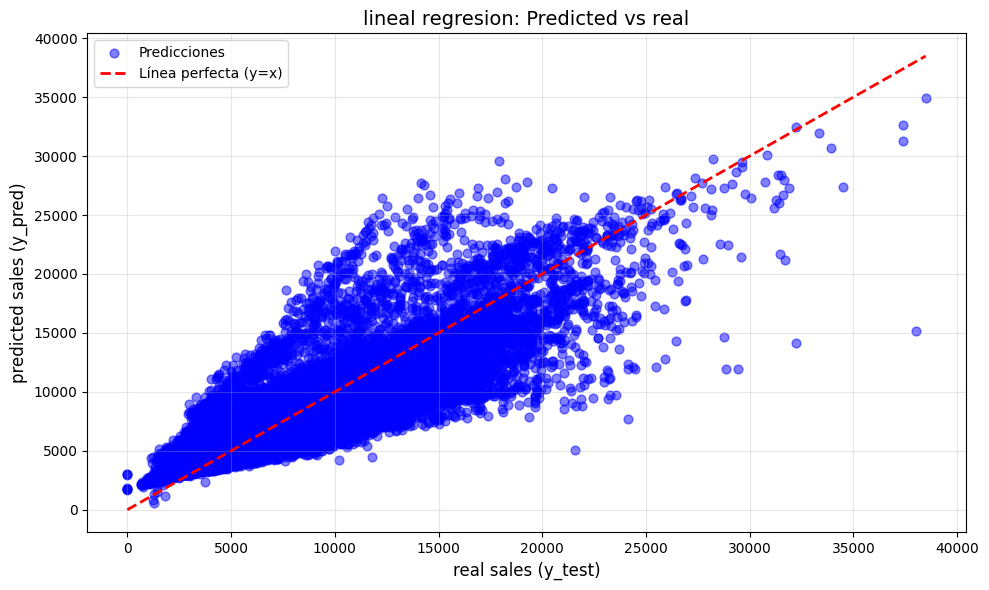

In [ ]:
#graph of linnear regresion
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction
y_pred = model.predict(X_test)
# ────────────────────────────────────────────────
# Graph1: predictions vs values
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', s=40, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Línea perfecta (y=x)')
plt.xlabel('real sales (y_test)', fontsize=12)
plt.ylabel('predicted sales (y_pred)', fontsize=12)
plt.title('lineal regresion: Predicted vs real', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Get the dates corresponding to the test set
# dates_for_plot = df_with_stores_open.loc[X_test.index, 'date']

# plt.figure(figsize=(14, 7))
# plt.plot(dates_for_plot, y_test, label='Real Sales', color='blue', alpha=0.7)
# plt.plot(dates_for_plot, y_pred, label='Predictions', color='orange', linestyle='--')
# plt.xlabel('Date', fontsize=12)
# plt.ylabel('Sales', fontsize=12)
# plt.title('Real vs Predicted Sales Over Time (Test Set)', fontsize=14)
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [ ]:
#second method of analysis, decision trees regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree RMSE: 2139.623987890403
Decision Tree R2: 0.5282775181052879


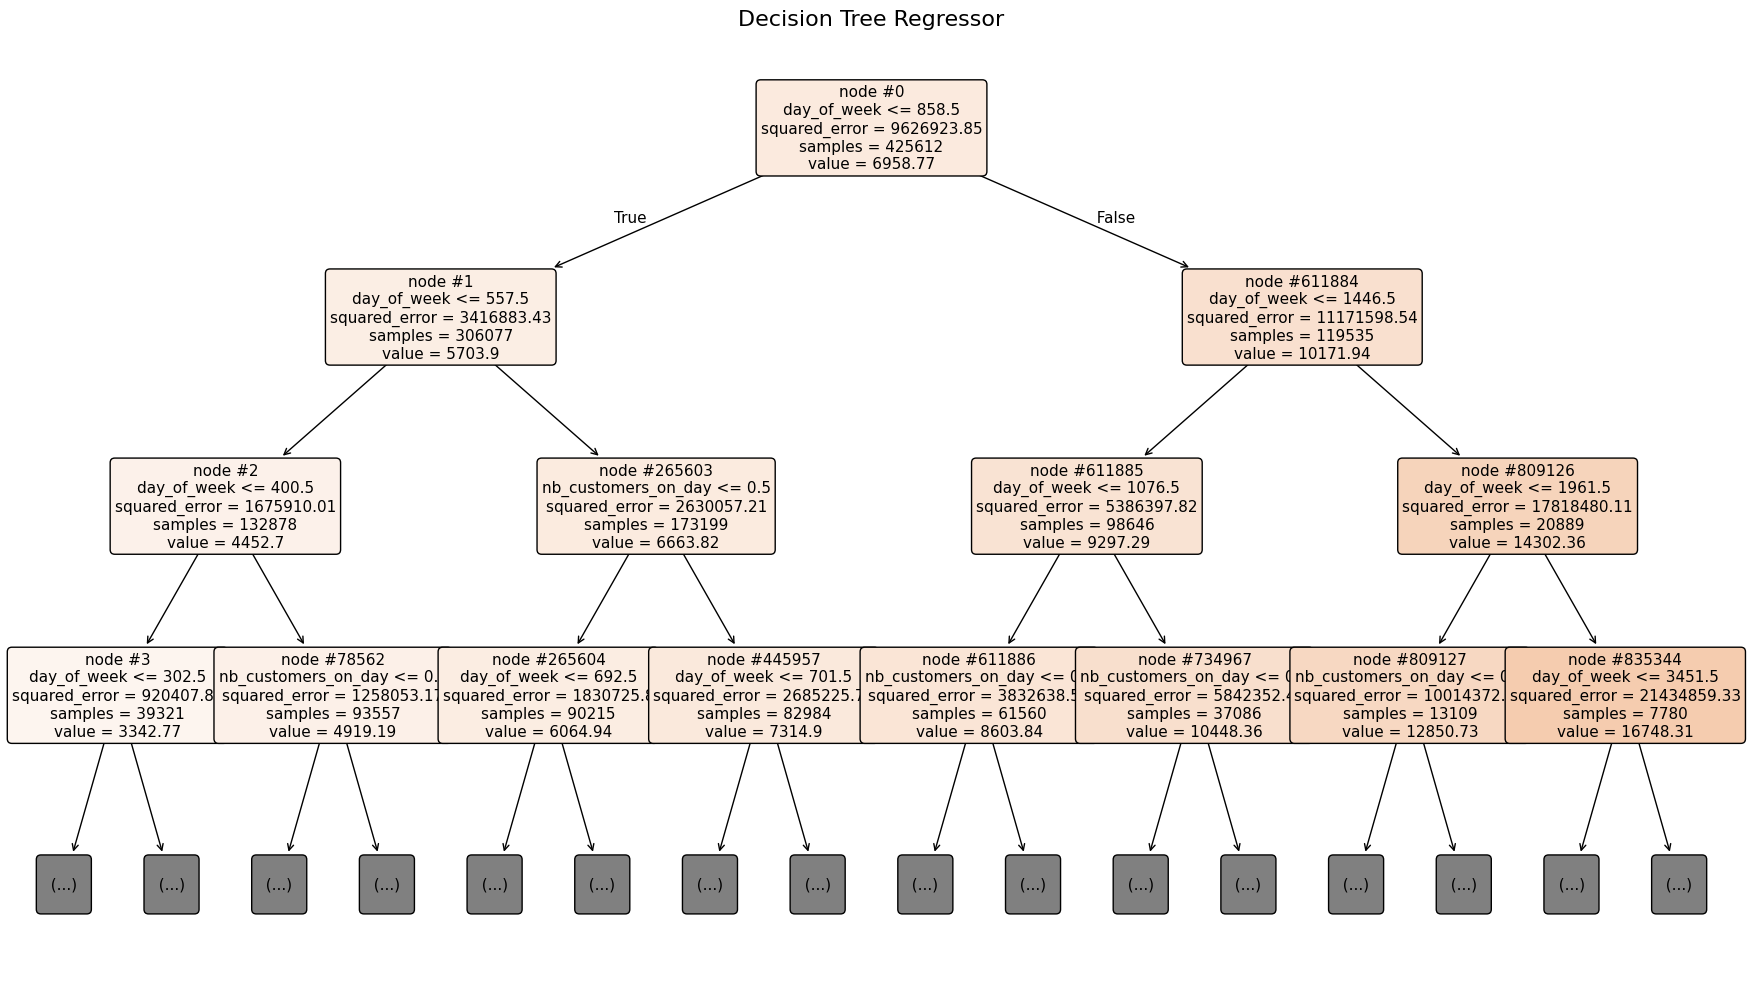

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))          # make it bigger so text is readable
plot_tree(
    dt_model,
    feature_names= df_with_stores_open.columns,      # ← replace with your real feature names: X.columns.tolist()
    filled=True,                      # colors the nodes
    rounded=True,
    fontsize=11,
    precision=2,                      # decimals in split values
    impurity=True,
    max_depth=3,                     # shows MSE / variance reduction
    node_ids=True                     # optional: shows node numbers
)

plt.title("Decision Tree Regressor", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df_with_stores_open.columns

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='object')

# Random Forest Regression

In [ ]:
# Random forest method and compare results
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=100,       # nmber of estimators
    max_depth=20,         # N
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # usa todos los núcleos → más rápido
)

# Fit method
rf.fit(X_train, y_train)
print("Model trained")

In [ ]:
# Store predictions in a new variable to avoid overwriting y_test
y_pred_rf = rf.predict(X_test)
print("Predictions done")
print(y_pred_rf)

In [ ]:
# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Using y_test (Actual) and y_pred_rf (Predicted)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)

# Random Forest Graphics


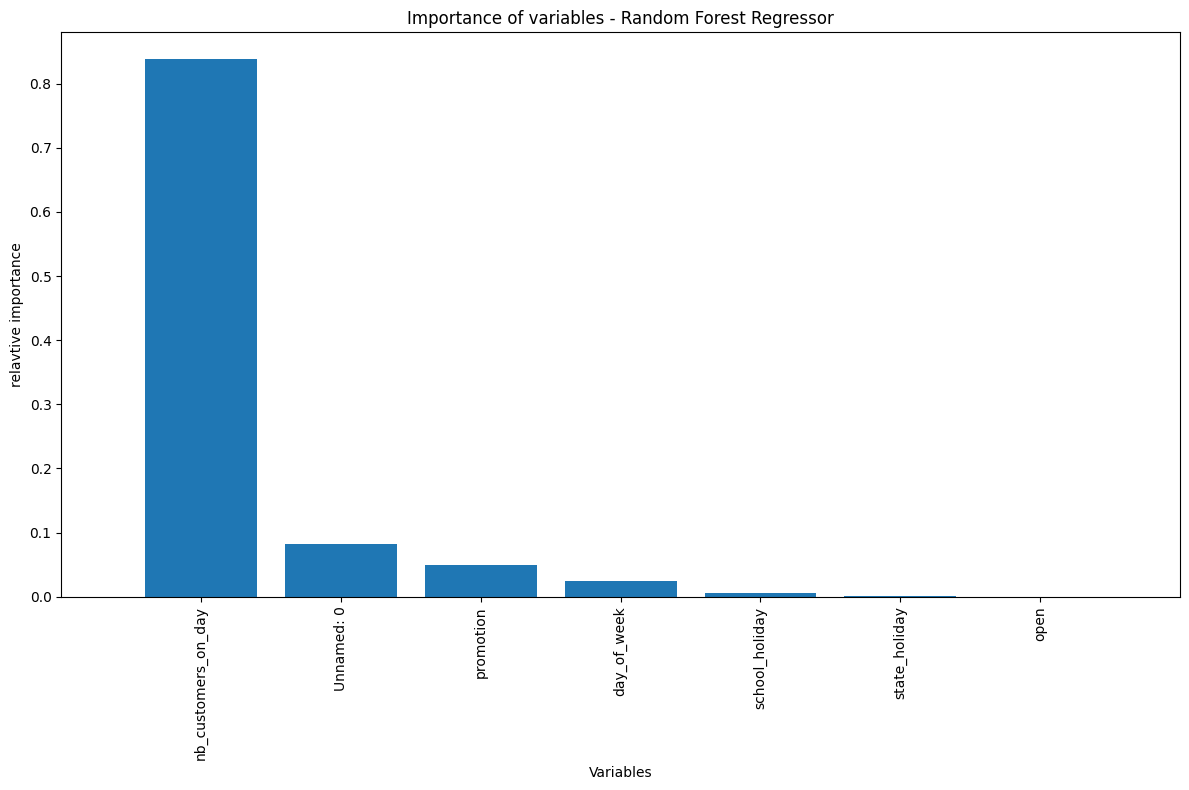

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importancia de features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # order desc

plt.figure(figsize=(12, 8))
plt.title("Importance of variables - Random Forest Regressor")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Variables")
plt.ylabel("relavtive importance")
plt.tight_layout()
plt.show()

In [ ]:
X_2 = df_with_stores_open[["nb_customers_on_day","promotion"]]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2,y, random_state = 0, test_size = 0.20)


In [ ]:
rf_2 = RandomForestRegressor(
    n_estimators=100,       # nmber of estimators
    max_depth=3,         # N
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # usa todos los núcleos → más rápido
)

# Fit method
rf_2.fit(X_train_2, y_train_2)
print("Model trained")

In [ ]:
# Store predictions in a new variable to avoid overwriting y_test
y_pred_rf_2 = rf_2.predict(X_test_2)
print("Predictions done")
print(y_pred_rf_2)

In [ ]:
# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Using y_test (Actual) and y_pred_rf (Predicted)
rmse_rf_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_rf_2))
r2_rf_2 = r2_score(y_test_2, y_pred_rf_2)
mae_rf_2 = mean_absolute_error(y_test_2, y_pred_rf_2)

print("Random Forest RMSE:", rmse_rf_2)
print("Random Forest R2:", r2_rf_2)
print("Random Forest MAE:", mae_rf_2)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importancia de features
importances = rf_2.feature_importances_
indices = np.argsort(importances)[::-1]  # order desc

plt.figure(figsize=(12, 8))
plt.title("Importance of variables - Random Forest Regressor")
plt.bar(range(X_2.shape[1]), importances[indices], align="center")
plt.xticks(range(X_2.shape[1]), [X_2.columns[i] for i in indices], rotation=90)
plt.xlim([-1, X_2.shape[1]])
plt.xlabel("Variables")
plt.ylabel("relavtive importance")
plt.tight_layout()
plt.show()

# Linear Regression Improved

In [ ]:
from sklearn.base import np
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)
# Make predictios
y_pred_train_2 = model_2.predict(X_train_2)
y_pred_test_2  = model_2.predict(X_test_2)
#Evaluate the model
rmse_train_2 = np.sqrt(mean_squared_error(y_train_2, y_pred_train_2))
rmse_test_2  = np.sqrt(mean_squared_error(y_test_2,  y_pred_test_2))
r2_train_2   = r2_score(y_train_2, y_pred_train_2)
r2_test_2   = r2_score(y_test_2,  y_pred_test_2)
print(f"rmse_test {rmse_test_2} , r2_test {r2_test_2}")


In [ ]:
#graph of linnear regresion
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction
y_pred_2 = model_2.predict(X_test_2)
# ────────────────────────────────────────────────
# Graph1: predictions vs values
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(y_test_2, y_pred_2, alpha=0.5, color='blue', s=40, label='Predicciones')
plt.plot([y_test_2.min(), y_test_2.max()], [y_test_2.min(), y_test_2.max()],
         color='red', linestyle='--', linewidth=2, label='Línea perfecta (y=x)')
plt.xlabel('real sales (y_test)', fontsize=12)
plt.ylabel('predicted sales (y_pred)', fontsize=12)
plt.title('lineal regresion: Predicted vs real', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Test with real data



In [ ]:
r_data = pd.read_csv('/content/REAL_DATA.csv')

r_df = perform_data_cleanup(r_data)

r_y_pred_2 = model_2.predict(r_df[["nb_customers_on_day","promotion"]])

result = r_df.iloc




In [ ]:
r_df['predicted_sales'] = r_y_pred_2
display(r_df.head())

r_df.to_csv('predicted_sales.csv', columns=["index", "predicted_sales"])